In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "text.usetex": False,     
    "font.family": "serif",
    "mathtext.fontset": "cm", 
    #"font.size": 12,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2
})



In [2]:
import os

print(os.getcwd())

c:\Users\Julian Samuel\Documents\GitHub\Protuberance-Optimization\Codes


In [3]:
route_cam8 = "C:/Users/Julian Samuel/Documents/GitHub/Protuberance-Optimization/Datos_sim cam 8"

files = {}

for file in os.listdir(route_cam8):
    if file.endswith(".csv"):
        data = pd.read_csv(os.path.join(route_cam8, file), skiprows=4)
        files[file] = data
print(files.keys())

print(files["cp_1000_z.csv"].head())

dict_keys(['cp1000_y.csv', 'cp_1000.csv', 'cp_1000_z.csv', 'cp_cam_y.csv', 'Cp_cross.csv', 'cp_curve_cam.csv'])
    Z [ m ]  Pressure Coefficient
0  0.183960             -0.006008
1  0.187231             -0.003796
2  0.189652             -0.002870
3  0.190792             -0.004130
4  0.190811             -0.004169


74 74


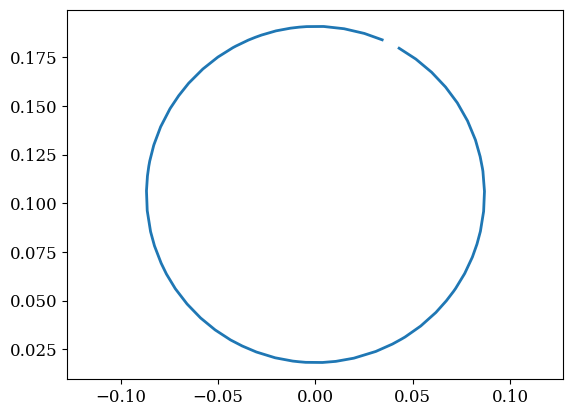

In [6]:
z = files["cp_1000_z.csv"]["Z [ m ]"]
y = files["cp1000_y.csv"]["Y [ m ]"]
print(len(z),len(y))
plt.figure()
plt.plot(y, z)
plt.axis('equal')
plt.show()

In [4]:
route_opt = "C:/Users/Julian Samuel/Documents/GitHub/Protuberance-Optimization/datos sim optim"

files_optim = {}

for file in os.listdir(route_opt):
    if file.endswith(".csv"):
        data = pd.read_csv(os.path.join(route_opt, file), skiprows=4)
        files_optim[file] = data
print(files_optim.keys())

print(files_optim["cp1000_z.csv"].head())

dict_keys(['cp1000_z.csv', 'cp_1000_y.csv', 'cp_cam.csv', 'cp_crossaxial.csv'])
    Z [ m ]  Pressure Coefficient
0  0.174943             -0.017011
1  0.180077             -0.009255
2  0.183918             -0.006062
3  0.187053             -0.004263
4  0.189343             -0.003539


In [7]:
z_optim = files_optim["cp1000_z.csv"]["Z [ m ]"]
y_optim = files_optim["cp_1000_y.csv"]["Y [ m ]"]
print(len(z),len(y))


74 74


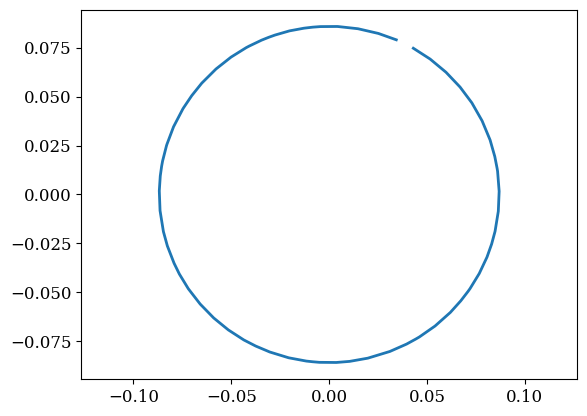

In [9]:
def rot_marix(pitch, roll):
    M_pitch = np.array([
        
        [np.cos(pitch), 0, -np.sin(pitch)],
        [0, 1, 0],
        [np.sin(pitch), 0, np.cos(pitch)]
        
        ])

    M_roll = np.array([
        [1, 0, 0],
        [0, np.cos(roll), -np.sin(roll)],
        [0, np.sin(roll), np.cos(roll)]
        ])
    return M_pitch @ M_roll



x = np.ones(len(z))*np.cos(np.radians(6)) 
r = list(zip(x, y, z))
r_shaped = r @ rot_marix(np.radians(6), np.radians(0))

r_optim = list(zip(x, y_optim, z_optim))
r_optim_shaped = r_optim @ rot_marix(np.radians(6), np.radians(0))


plt.figure()
plt.plot(r_shaped[:, 1], r_shaped[:, 2])
plt.axis('equal')
plt.show()


In [10]:
ref = np.array([0, min(r_shaped[:, 2])])   # (y,z)

yz = r_shaped[:, 1:3]
cross = ref[0]*yz[:, 1] - ref[1]*yz[:, 0]
dot = ref[0]*yz[:, 0] + ref[1]*yz[:, 1]

theta = np.degrees(np.arctan2(cross, dot))

theta = np.mod(theta, 180)
theta

array([156.54470701, 163.00637031, 170.14302986, 177.0551147 ,
       177.3635128 ,   3.01850653,   5.57392863,   8.61425388,
        13.59636442,  13.67567907,  18.77701084,  21.11124198,
        23.63484861,  28.35374282,  29.49495612,  35.53699858,
        42.06505251,  48.87082744,  54.30333278,  59.30619859,
        59.7165041 ,  66.51185731,  66.5251533 ,  72.86863883,
        73.38476471,  78.64720048,  80.43939383,  83.75702521,
        88.7864703 ,  95.46954389, 102.63812905, 107.63039156,
       113.90102054, 117.9869901 , 123.80628199, 130.33365789,
       136.92301107, 143.33616429, 149.55489066, 149.71028943,
       154.12089891, 159.34628877, 166.06895175, 172.19688524,
       174.35075512, 176.65061486,   2.40431937,   7.00226404,
        13.2661288 ,  21.13349537,  27.33711406,  30.94491032,
        32.32683857,  38.81561437,  45.75940282,  51.05481567,
        55.02235921,  56.25483592,  62.20960457,  68.34343544,
        73.02350896,  77.46722487,  84.29678635,  91.05

In [26]:
ref = np.array([0, min(r_optim_shaped[:, 2])])   # (y,z)

yz_optim = r_optim_shaped[:, 1:3]
cross_o = ref[0]*yz_optim[:, 1] - ref[1]*yz_optim[:, 0]
dot_o = ref[0]*yz_optim[:, 0] + ref[1]*yz_optim[:, 1]

theta_o = np.degrees(np.arctan2(cross_o, dot_o))

theta_o = np.mod(theta_o, 180)
theta_o

array([144.28478253, 150.64240679, 156.48289776, 162.55615077,
       168.91102569, 174.85668111, 176.68964139,   0.28274594,
         5.20311806,   6.07239858,  12.78485303,  20.26842635,
        27.80864724,  33.4784426 ,  38.78072286,  46.16557787,
        50.96450724,  57.59561754,  64.80015618,  67.31545305,
        70.36002568,  75.56574212,  77.39370271,  82.3093712 ,
        83.18110657,  89.42701457,  96.32756118, 103.19567487,
       108.9756001 , 111.73583832, 114.54790492, 120.24682397,
       126.8431961 , 131.07740432, 138.486706  , 146.10746011,
       153.77952762, 161.30677211, 166.7687358 , 174.17884487,
       178.25993188, 179.49311851,   3.21817434,   9.2347299 ,
        14.68452514,  20.41526729,  27.02843294,  31.19496618,
        37.99846306,  44.57471664,  51.95114647,  56.24240583,
        62.89378399,  69.93293393,  70.13575632,  75.75590051,
        78.70221768,  80.98071393,  86.88908604,  93.5885718 ,
       100.23236936, 106.14331614, 106.48380915, 110.99

In [28]:
data_shaped = pd.DataFrame({
    "theta": theta,
    "Cp": files["cp_1000_z.csv"]["Pressure Coefficient"],
    "y": r_shaped[:, 1],
    "z": r_shaped[:, 2]
})
data_shaped

data_optim_shaped = pd.DataFrame({
    "theta": theta_o,
    "Cp": files_optim["cp1000_z.csv"]["Pressure Coefficient"],
    "y": r_optim_shaped[:, 1],
    "z": r_optim_shaped[:, 2]
})



In [29]:
# Camera 8
starboard = data_shaped[y >= 0]
port = data_shaped[y < 0]
starboard = starboard.sort_values("theta")
port = port.sort_values("theta")
port["theta"] = np.abs(port["theta"] -180)

# optim

starboard_optim = data_optim_shaped[y_optim >= 0]
port_optim = data_optim_shaped[y_optim < 0]
starboard_optim = starboard_optim.sort_values("theta")
port_optim = port_optim.sort_values("theta")
port_optim["theta"] = np.abs(port_optim["theta"] -180)

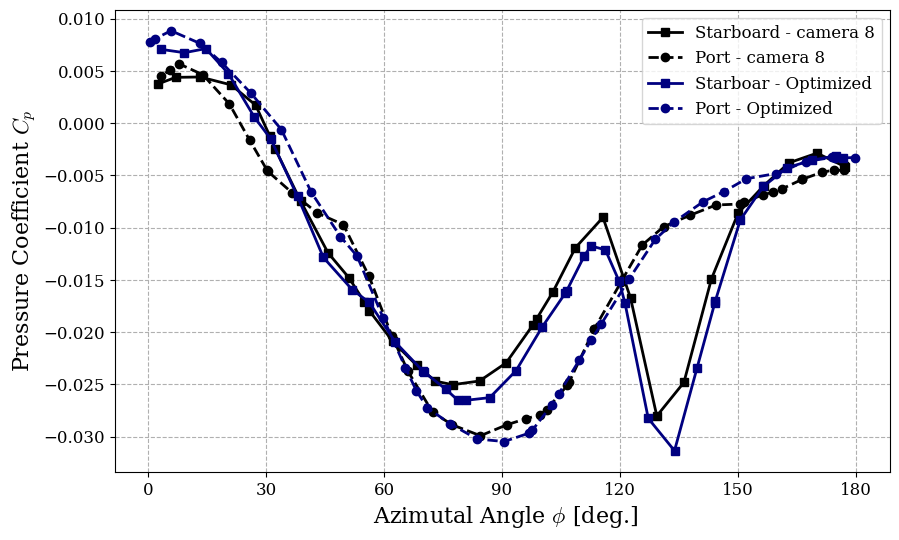

In [ ]:
plt.figure(figsize=(10, 6))
#plt.scatter(theta_pos["theta"], theta_pos["Cp"], label="Cp cam 8 upper")
#plt.scatter(theta_neg["theta"], theta_neg["Cp"], label="Cp cam 8 lower")
plt.plot(starboard["theta"], starboard["Cp"], marker = "s", label="Starboard - camera 8", color = "k")
plt.plot(port["theta"], port["Cp"], marker = "o", label="Port - camera 8", color = "k", linestyle = "--")
plt.plot(starboard_optim["theta"], starboard_optim["Cp"], marker = "s", label = "Starboar - Optimized", color = "navy")
plt.plot(port_optim["theta"], port_optim["Cp"], marker = "o", label = "Port - Optimized", linestyle = "--", color= "navy")

plt.plot([45, 45], [data_optim_shaped["Cp"].min() - 0.005, data_optim_shaped["Cp"].max() + 0.005], linestyle = "-.", label = "rail button", color = "red")
plt.plot([45, 45], [data_optim_shaped["Cp"].min() - 0.005, data_optim_shaped["Cp"].max() + 0.005], linestyle = "-.", label = "Camera", color = "red")
plt.xlabel(" Azimutal Angle $\\phi$ [deg.]")
plt.ylabel("Pressure Coefficient $C_p$")
#plt.title(" vs")
plt.xticks(np.arange(0,181, 30))
plt.grid(linestyle='--')
plt.legend()
plt.show()

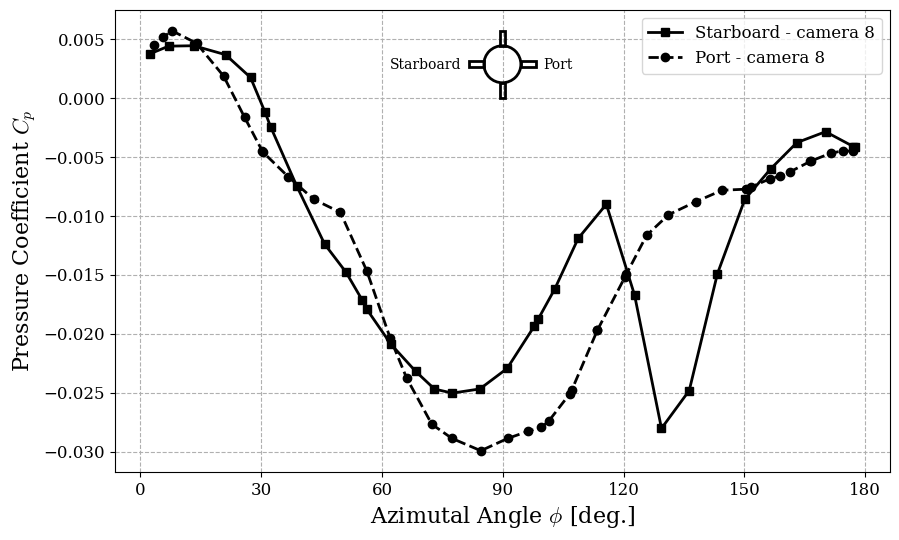

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(starboard["theta"], starboard["Cp"],
        marker="s", label="Starboard - camera 8",
        color="k")

ax.plot(port["theta"], port["Cp"],
        marker="o", label="Port - camera 8",
        color="k", linestyle="--")

ax.set_xlabel("Azimutal Angle $\\phi$ [deg.]")
ax.set_ylabel("Pressure Coefficient $C_p$")
ax.set_xticks(np.arange(0, 181, 30))
ax.grid(linestyle='--')
ax.legend()

# --------------------------------------------------
# Crear eje interno en el centro
# --------------------------------------------------
ax_inset = inset_axes(
    ax,
    width="20%",
    height="20%",
    loc="upper center"
)

ax_inset.set_aspect("equal")

# Círculo central
circle = Circle((0, 0), 1, fill=False, linewidth=2)
ax_inset.add_patch(circle)

# Rectángulo superior
ax_inset.add_patch(
    Rectangle((-0.15, 1), 0.3, 0.8, fill=False, linewidth=2)
)

# Rectángulo inferior
ax_inset.add_patch(
    Rectangle((-0.15, -1.8), 0.3, 0.8, fill=False, linewidth=2)
)

# Rectángulo izquierdo
ax_inset.add_patch(
    Rectangle((-1.8, -0.15), 0.8, 0.3, fill=False, linewidth=2)
)

# Rectángulo derecho
ax_inset.add_patch(
    Rectangle((1, -0.15), 0.8, 0.3, fill=False, linewidth=2)
)

# Etiquetas
ax_inset.text(-2.2, 0, "Starboard",
              ha="right", va="center")

ax_inset.text(2.2, 0, "Port",
              ha="left", va="center")

# Ocultar ejes
ax_inset.set_xlim(-2.5, 2.5)
ax_inset.set_ylim(-2.5, 2.5)
ax_inset.axis("off")


plt.show()